Accuracy: 0.7374301675977654
[[93 12]
 [35 39]]
Passenger Did Not Survive


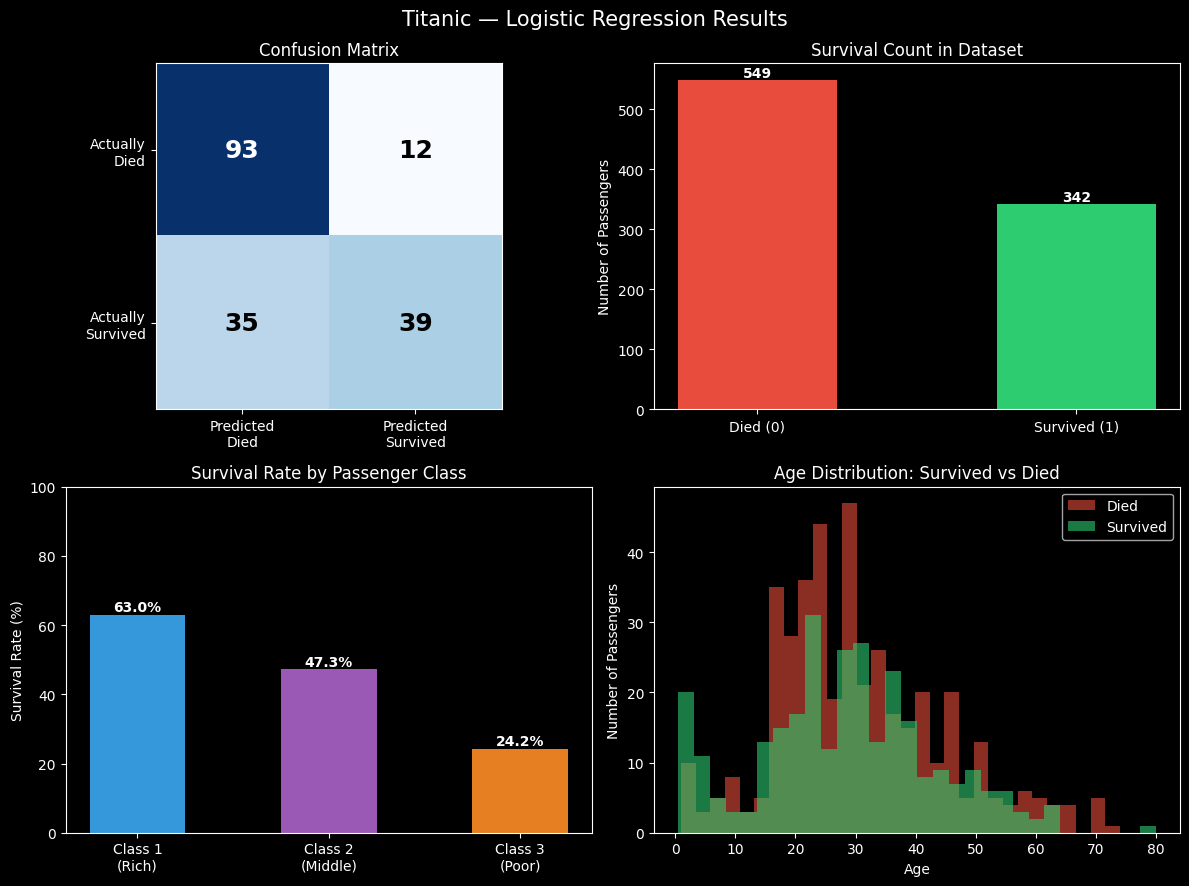


Chart saved as titanic_charts.png


In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt   # NEW
import numpy as np                 # NEW

# ── Your original code (unchanged) ──────────────────────────
data = pd.read_csv('train.csv')   # fixed typo: tren → train

X = data[['Pclass', 'Age', 'Fare']]
X['Age'] = X['Age'].fillna(X['Age'].mean())
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

new_passenger = [[3, 22, 7.5]]
prediction = model.predict(new_passenger)
if prediction[0] == 1:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survive")

# ── NEW: 4 Visualizations ────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Titanic — Logistic Regression Results', fontsize=15)

# ── Chart 1: Confusion Matrix ─────────────────────────────────
ax = axes[0, 0]
cm = confusion_matrix(y_test, y_pred)
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted\nDied', 'Predicted\nSurvived'])
ax.set_yticklabels(['Actually\nDied', 'Actually\nSurvived'])
ax.set_title('Confusion Matrix')
# Write the numbers inside each box
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center', fontsize=18, fontweight='bold',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

# ── Chart 2: Survival Count ───────────────────────────────────
ax = axes[0, 1]
counts = y.value_counts()
bars = ax.bar(['Died (0)', 'Survived (1)'],
              [counts[0], counts[1]],
              color=['#e74c3c', '#2ecc71'], width=0.5)
ax.set_title('Survival Count in Dataset')
ax.set_ylabel('Number of Passengers')
# Write count on top of each bar
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            str(int(bar.get_height())),
            ha='center', fontweight='bold')

# ── Chart 3: Survival Rate by Passenger Class ────────────────
ax = axes[1, 0]
survival_by_class = data.groupby('Pclass')['Survived'].mean() * 100
bars = ax.bar(['Class 1\n(Rich)', 'Class 2\n(Middle)', 'Class 3\n(Poor)'],
              survival_by_class.values,
              color=['#3498db', '#9b59b6', '#e67e22'], width=0.5)
ax.set_title('Survival Rate by Passenger Class')
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 100)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'{bar.get_height():.1f}%',
            ha='center', fontweight='bold')

# ── Chart 4: Age Distribution — Survived vs Died ─────────────
ax = axes[1, 1]
died     = data[data['Survived'] == 0]['Age'].dropna()
survived = data[data['Survived'] == 1]['Age'].dropna()
ax.hist(died,     bins=30, alpha=0.6, color='#e74c3c', label='Died')
ax.hist(survived, bins=30, alpha=0.6, color='#2ecc71', label='Survived')
ax.set_title('Age Distribution: Survived vs Died')
ax.set_xlabel('Age')
ax.set_ylabel('Number of Passengers')
ax.legend()

plt.tight_layout()
plt.savefig('titanic_charts.png', dpi=130, bbox_inches='tight')
plt.show()
print("\nChart saved as titanic_charts.png")